<a href="https://colab.research.google.com/github/kanishkaa-15/final_year_project1/blob/main/project_fed_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y torchao
!pip install -U torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.9 MB/s eta 0:00:00


In [2]:
!pip install -U peft
!pip install -U torchao

In [3]:
!pip install -q \
transformers==4.45.2 \
peft==0.13.2 \
accelerate==1.0.1 \
datasets==3.0.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 49.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 whic

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'project']


In [6]:
import transformers
import peft
import torch

print("Transformers :", transformers.__version__)
print("PEFT         :", peft.__version__)
print("Torch        :", torch.__version__)

Transformers : 4.45.2
PEFT         : 0.13.2
Torch        : 2.11.0+cu128


In [7]:
!pip show transformers
!pip show peft

Name: transformers
Version: 4.45.2
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers
Name: peft
Version: 0.13.2
Summary: Parameter-Efficient Fine-Tuning (PEFT)
Home-page: https://github.com/huggingface/peft
Author: The HuggingFace team
Author-email: benjamin@huggingface.co
License: Apache
Location: /usr/local/lib/python3.12/dist-packages
Requires: accelerate, huggingface-hub, numpy, packaging, psutil, pyyaml, safetensors, torch, tqdm, transformers
Required-by: 


Module 1 : Data Loading
 Project:
Adaptive Personalized Federated Learning
for Privacy-Preserving Next Word Prediction

In [8]:
# ============================================
# Module 1 : Data Loading
# Project:
# Adaptive Personalized Federated Learning
# for Privacy-Preserving Next Word Prediction
# ============================================

import os
import pandas as pd

# -------------------------------------------------
# Dataset Path
# -------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/project/dataset"

# -------------------------------------------------
# Dataset Names
# -------------------------------------------------

DATASETS = {
    "shakespeare": "Shakespeare_cleaned.csv",
    "tamil_news": "tamil_news_cleaned.csv",
    "tanglish": "tanglish.csv",
    "codemix": "codemix.csv",
    "movie_reviews": "tamil_movie_reviews_test (3).csv",
    "colloquial": "colloquial.csv"
}

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

def load_dataset(dataset_name, filename):

    file_path = os.path.join(DATASET_PATH, filename)

    if not os.path.exists(file_path):
        print(f"❌ {filename} not found.")
        return None

    df = pd.read_csv(file_path)

    print("="*60)
    print(f"Dataset : {dataset_name}")
    print("="*60)

    print(f"Shape : {df.shape}")

    print("\nColumns")
    print(df.columns.tolist())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nFirst 5 Rows")
    print(df.head())

    print()

    return df

# -------------------------------------------------
# Load All Datasets
# -------------------------------------------------

def load_all_datasets():

    dataset_dict = {}

    for dataset_name, filename in DATASETS.items():

        dataset_dict[dataset_name] = load_dataset(
            dataset_name,
            filename
        )

    return dataset_dict

# -------------------------------------------------
# Main
# -------------------------------------------------

if __name__ == "__main__":

    datasets = load_all_datasets()

    print("\nSuccessfully Loaded Datasets")

    print(list(datasets.keys()))

Dataset : shakespeare
Shape : (108741, 1)

Columns
['PlayerLine']

Missing Values
PlayerLine    0
dtype: int64

First 5 Rows
                                      PlayerLine
0         so shaken as we are, so wan with care,
1     find we a time for frighted peace to pant,
2  and breathe shortwinded accents of new broils
3        to be commenced in strands afar remote.
4      no more the thirsty entrance of this soil

Dataset : tamil_news
Shape : (14521, 2)

Columns
['NewsInTamil', 'CategoryInTamil']

Missing Values
NewsInTamil        0
CategoryInTamil    0
dtype: int64

First 5 Rows
                                         NewsInTamil CategoryInTamil
0         ஈராக்கில் 43 ஆண்டுகள் கழித்து அழகிப்போட்டி           உலகம்
1  இந்திய அளவில் ட்ரெண்ட் ஆன அஜித்தின் தள்லே தில்...          சினிமா
2  சொந்த செலவில் வாகன காப்பீடு எடுத்து கொடுத்த கா...       தமிழ்நாடு
3              பிறந்தநாளில் பட்ஜெட் தாக்கல் செய்தவர்         இந்தியா
4  நானா? பாஜகவில் இணைந்துவிட்டேனா  வரலட்சுமி விளக...          சினி

In [9]:
import os
import pandas as pd

DATASET_PATH = "/content/drive/MyDrive/project/dataset"

for file in os.listdir(DATASET_PATH):

    if file.endswith(".csv"):

        print("="*70)
        print(file)

        df = pd.read_csv(os.path.join(DATASET_PATH, file))

        print(df.columns.tolist())

tanglish.csv
['text', 'label']
codemix.csv
['text', 'label']
colloquial.csv
['Colloquial_Text']
Shakespeare_cleaned.csv
['PlayerLine']
tamil_movie_reviews_test (3).csv
['ReviewId', 'ReviewInTamil', 'Rating']
tamil_news_cleaned.csv
['NewsInTamil', 'CategoryInTamil']


Module 2 : Data Preprocessing

In [10]:
# ============================================
# Module 2 : Data Preprocessing
# Adaptive Personalized Federated Learning
# ============================================

import os
import re
import pandas as pd

# ----------------------------------------------------
# Paths
# ----------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/project/dataset"
SAVE_PATH = "/content/drive/MyDrive/project/processed_dataset"

os.makedirs(SAVE_PATH, exist_ok=True)

# ----------------------------------------------------
# Dataset Configuration
# ----------------------------------------------------

DATASETS = {

    "shakespeare": {
        "file": "Shakespeare_cleaned.csv",
        "text_column": "PlayerLine"
    },

    "tamil_news": {
        "file": "tamil_news_cleaned.csv",
        "text_column": "NewsInTamil"
    },

    "tanglish": {
        "file": "tanglish.csv",
        "text_column": "text"
    },

    "codemix": {
        "file": "codemix.csv",
        "text_column": "text"
    },

    "movie_reviews": {
        "file": "tamil_movie_reviews_test (3).csv",
        "text_column": "ReviewInTamil"
    },

    "colloquial": {
        "file": "colloquial.csv",
        "text_column": "Colloquial_Text"
    }

}

# ----------------------------------------------------
# Text Cleaning
# ----------------------------------------------------

def clean_text(text):

    text = str(text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text


# ----------------------------------------------------
# Preprocess One Dataset
# ----------------------------------------------------

def preprocess_dataset(file_name, text_column):

    file_path = os.path.join(DATASET_PATH, file_name)

    df = pd.read_csv(file_path)

    # Keep only text column
    df = df[[text_column]].copy()

    # Rename to common name
    df.columns = ["text"]

    # Remove null values
    df.dropna(inplace=True)

    # Convert to string
    df["text"] = df["text"].astype(str)

    # Clean text
    df["text"] = df["text"].apply(clean_text)

    # Remove empty rows
    df = df[df["text"] != ""]

    df = df[df["text"] != "nan"]

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)

    # Reset index
    df.reset_index(drop=True, inplace=True)

    return df


# ----------------------------------------------------
# Process All Datasets
# ----------------------------------------------------

def preprocess_all():

    processed = {}

    print("=" * 70)
    print("Starting Data Preprocessing")
    print("=" * 70)

    for dataset_name, info in DATASETS.items():

        print(f"\nProcessing : {dataset_name}")

        df = preprocess_dataset(

            info["file"],
            info["text_column"]

        )

        save_file = os.path.join(

            SAVE_PATH,

            dataset_name + ".csv"

        )

        df.to_csv(save_file, index=False)

        processed[dataset_name] = df

        print(f"Samples : {len(df)}")
        print(f"Saved    : {save_file}")

    print("\nAll datasets processed successfully.")

    return processed


# ----------------------------------------------------
# Main
# ----------------------------------------------------

if __name__ == "__main__":

    datasets = preprocess_all()

    print("\nExample:")

    for name, df in datasets.items():

        print("\n", "="*40)
        print(name)
        print(df.head())

Starting Data Preprocessing

Processing : shakespeare
Samples : 105506
Saved    : /content/drive/MyDrive/project/processed_dataset/shakespeare.csv

Processing : tamil_news
Samples : 10574
Saved    : /content/drive/MyDrive/project/processed_dataset/tamil_news.csv

Processing : tanglish
Samples : 11235
Saved    : /content/drive/MyDrive/project/processed_dataset/tanglish.csv

Processing : codemix
Samples : 34876
Saved    : /content/drive/MyDrive/project/processed_dataset/codemix.csv

Processing : movie_reviews
Samples : 114
Saved    : /content/drive/MyDrive/project/processed_dataset/movie_reviews.csv

Processing : colloquial
Samples : 200
Saved    : /content/drive/MyDrive/project/processed_dataset/colloquial.csv

All datasets processed successfully.

Example:

shakespeare
                                            text
0         so shaken as we are, so wan with care,
1     find we a time for frighted peace to pant,
2  and breathe shortwinded accents of new broils
3        to be commenced

Module 3 Tokenization for Causal Language Modeling

In [11]:
# ============================================
# Module 3
# Tokenization for Causal Language Modeling
# ============================================

import os
import pandas as pd

from datasets import Dataset
from transformers import AutoTokenizer

# ----------------------------------------------------
# Paths
# ----------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/project/processed_dataset"
SAVE_PATH = "/content/drive/MyDrive/project/tokenized_dataset"

os.makedirs(SAVE_PATH, exist_ok=True)

# ----------------------------------------------------
# Base Model
# ----------------------------------------------------

MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# GPT2 has no padding token
tokenizer.pad_token = tokenizer.eos_token

MAX_LENGTH = 128

# ----------------------------------------------------
# Tokenization Function
# ----------------------------------------------------

def tokenize_function(example):

    text = str(example["text"])

    if text.strip() == "":
        text = "[EMPTY]"

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    # Labels are same as input_ids for Causal LM
    tokens["labels"] = tokens["input_ids"].copy()

    return tokens


# ----------------------------------------------------
# Process One Dataset
# ----------------------------------------------------

def process_dataset(file_name):

    print("=" * 60)
    print(f"Processing : {file_name}")

    file_path = os.path.join(DATASET_PATH, file_name)

    # Read CSV
    df = pd.read_csv(file_path)

    # Check text column
    if "text" not in df.columns:
        raise ValueError(
            f"'text' column not found in {file_name}"
        )

    # Remove null values
    df = df.dropna(subset=["text"])

    # Convert to string
    df["text"] = df["text"].astype(str)

    # Remove empty rows
    df = df[df["text"].str.strip() != ""]

    # Reset index
    df.reset_index(drop=True, inplace=True)

    # Convert to HuggingFace Dataset
    dataset = Dataset.from_pandas(df)

    # Tokenization
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=False
    )

    # Save Folder
    save_folder = os.path.join(
        SAVE_PATH,
        os.path.splitext(file_name)[0]
    )

    tokenized_dataset.save_to_disk(save_folder)

    print("Saved :", save_folder)
    print("Samples :", len(tokenized_dataset))


# ----------------------------------------------------
# Process All Datasets
# ----------------------------------------------------

def process_all():

    files = sorted(os.listdir(DATASET_PATH))

    for file in files:

        if file.endswith(".csv"):

            process_dataset(file)


# ----------------------------------------------------
# Main
# ----------------------------------------------------

if __name__ == "__main__":

    process_all()

    print("\nTokenization Completed Successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/10574 [00:00<?, ? examples/s]

Saved : /content/drive/MyDrive/project/tokenized_dataset/tamil_news
Samples : 10574
Processing : tanglish.csv


Map:   0%|          | 0/11235 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11235 [00:00<?, ? examples/s]

Saved : /content/drive/MyDrive/project/tokenized_dataset/tanglish
Samples : 11235

Tokenization Completed Successfully.


Module 4
Federated Client Creation

In [12]:
# ============================================
# Module 4
# Federated Client Creation
# ============================================

import os
from datasets import load_from_disk

# --------------------------------------------
# Paths
# --------------------------------------------

TOKENIZED_PATH = "/content/drive/MyDrive/project/tokenized_dataset"

CLIENT_PATH = "/content/drive/MyDrive/project/clients"

os.makedirs(CLIENT_PATH, exist_ok=True)

# --------------------------------------------
# Number of Clients Per Dataset
# --------------------------------------------

CLIENT_SPLITS = {

    "shakespeare":3,

    "tamil_news":2,

    "tanglish":2,

    "codemix":2,

    "movie_reviews":1,

    "colloquial":1

}

# --------------------------------------------
# Create Clients
# --------------------------------------------

def create_clients(dataset_name):

    dataset_path = os.path.join(
        TOKENIZED_PATH,
        dataset_name
    )

    dataset = load_from_disk(dataset_path)

    n_clients = CLIENT_SPLITS[dataset_name]

    dataset = dataset.shuffle(seed=42)

    total = len(dataset)

    split_size = total // n_clients

    print()

    print("="*60)

    print(dataset_name)

    print("Total Samples :", total)

    print("Clients :", n_clients)

    for i in range(n_clients):

        start = i * split_size

        if i == n_clients-1:

            end = total

        else:

            end = (i+1) * split_size

        client_dataset = dataset.select(
            range(start,end)
        )

        train_test = client_dataset.train_test_split(

            test_size=0.2,

            seed=42

        )

        client_folder = os.path.join(

            CLIENT_PATH,

            f"client_{create_clients.client_id}"

        )

        os.makedirs(client_folder,exist_ok=True)

        train_test["train"].save_to_disk(

            os.path.join(

                client_folder,

                "train"

            )

        )

        train_test["test"].save_to_disk(

            os.path.join(

                client_folder,

                "test"

            )

        )

        print(

            f"Client {create_clients.client_id}",

            len(train_test["train"]),

            len(train_test["test"])

        )

        create_clients.client_id += 1

create_clients.client_id = 1

# --------------------------------------------
# Main
# --------------------------------------------

def main():

    for dataset in CLIENT_SPLITS.keys():

        create_clients(dataset)

    print()

    print("="*60)

    print("Federated Clients Created Successfully.")

if __name__ == "__main__":

    main()


shakespeare
Total Samples : 105506
Clients : 3


Saving the dataset (0/1 shards):   0%|          | 0/28134 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7034 [00:00<?, ? examples/s]

Client 1 28134 7034


Saving the dataset (0/1 shards):   0%|          | 0/28134 [00:00<?, ? examples/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/23 [00:00<?, ? examples/s]

Client 10 91 23

colloquial
Total Samples : 200
Clients : 1


Saving the dataset (0/1 shards):   0%|          | 0/160 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/40 [00:00<?, ? examples/s]

Client 11 160 40

Federated Clients Created Successfully.


In [13]:
# ==========================================================
# Module 5
# DistilGPT2 + PEFT (LoRA)
# ==========================================================

import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

# ==========================================================
# Configuration
# ==========================================================

MODEL_NAME = "distilgpt2"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Default LoRA Rank
DEFAULT_LORA_RANK = 8

# ==========================================================
# Load Tokenizer
# ==========================================================

def load_tokenizer():

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    tokenizer.pad_token = tokenizer.eos_token

    return tokenizer


# ==========================================================
# Load Base Model
# ==========================================================

def load_base_model():

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME
    )

    model.to(DEVICE)

    return model


# ==========================================================
# Freeze Base Model
# ==========================================================

def freeze_model(model):

    for param in model.parameters():

        param.requires_grad = False

    return model


# ==========================================================
# Create LoRA Configuration
# ==========================================================

def create_lora_config(rank=DEFAULT_LORA_RANK):

    config = LoraConfig(

        task_type=TaskType.CAUSAL_LM,

        r=rank,

        lora_alpha=32,

        lora_dropout=0.1,

        bias="none",

        target_modules=[
            "c_attn",
            "c_proj"
        ]

    )

    return config


# ==========================================================
# Attach LoRA
# ==========================================================

def attach_lora(model, rank=DEFAULT_LORA_RANK):

    config = create_lora_config(rank)

    model = get_peft_model(
        model,
        config
    )

    return model


# ==========================================================
# Print Trainable Parameters
# ==========================================================

def print_trainable_parameters(model):

    total_params = 0
    trainable_params = 0

    for param in model.parameters():

        total_params += param.numel()

        if param.requires_grad:

            trainable_params += param.numel()

    print("=" * 60)
    print("Model Summary")
    print("=" * 60)

    print(f"Total Parameters      : {total_params:,}")
    print(f"Trainable Parameters  : {trainable_params:,}")
    print(f"Frozen Parameters     : {total_params-trainable_params:,}")

    percentage = (
        trainable_params / total_params
    ) * 100

    print(f"Trainable Percentage  : {percentage:.4f}%")

    print("=" * 60)


# ==========================================================
# Build Complete PEFT Model
# ==========================================================

def build_peft_model(rank=DEFAULT_LORA_RANK):

    print("Loading Tokenizer...")

    tokenizer = load_tokenizer()

    print("Loading DistilGPT2...")

    model = load_base_model()

    print("Freezing Base Model...")

    model = freeze_model(model)

    print("Attaching LoRA...")

    model = attach_lora(
        model,
        rank
    )

    print_trainable_parameters(model)

    return tokenizer, model


# ==========================================================
# Save Model
# ==========================================================

def save_model(model, tokenizer, save_path):

    model.save_pretrained(save_path)

    tokenizer.save_pretrained(save_path)

    print(f"\nModel saved to:\n{save_path}")


# ==========================================================
# Main
# ==========================================================

if __name__ == "__main__":

    tokenizer, model = build_peft_model()

    # Optional
    # save_model(
    #     model,
    #     tokenizer,
    #     "/content/drive/MyDrive/project/lora_model"
    # )

Loading Tokenizer...
Loading DistilGPT2...


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Freezing Base Model...
Attaching LoRA...
Model Summary
Total Parameters      : 82,318,080
Trainable Parameters  : 405,504
Frozen Parameters     : 81,912,576
Trainable Percentage  : 0.4926%


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:1150: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [14]:
# ==========================================================
# Module 6
# Adaptive LoRA Rank Selection
# ==========================================================

import os
from datasets import load_from_disk

# ----------------------------------------------------------
# Client Folder
# ----------------------------------------------------------

CLIENT_PATH = "/content/drive/MyDrive/project/clients"

# ----------------------------------------------------------
# Rank Limits
# ----------------------------------------------------------

MIN_RANK = 4
MAX_RANK = 16

# ----------------------------------------------------------
# Count Samples
# ----------------------------------------------------------

def get_client_size(client_folder):

    train_path = os.path.join(
        client_folder,
        "train"
    )

    train_dataset = load_from_disk(train_path)

    return len(train_dataset)

# ----------------------------------------------------------
# Adaptive Rank Function
# ----------------------------------------------------------

def calculate_rank(dataset_size):

    if dataset_size >= 20000:
        return 16

    elif dataset_size >= 10000:
        return 12

    elif dataset_size >= 5000:
        return 8

    else:
        return 4

# ----------------------------------------------------------
# Assign Rank
# ----------------------------------------------------------

def assign_ranks():

    client_rank = {}

    client_list = sorted(
    os.listdir(CLIENT_PATH),
    key=lambda client: int(client.split("_")[1])
    )

    for client in client_list:

        client_folder = os.path.join(
            CLIENT_PATH,
            client
        )

        if not os.path.isdir(client_folder):
            continue

        size = get_client_size(client_folder)

        rank = calculate_rank(size)

        client_rank[client] = {

            "samples": size,

            "rank": rank

        }

    return client_rank

# ----------------------------------------------------------
# Display
# ----------------------------------------------------------

def display_rank_table(rank_dict):

    print("=" * 65)

    print("{:<12} {:<15} {:<10}".format(
        "Client",
        "Samples",
        "LoRA Rank"
    ))

    print("=" * 65)

    for client, info in rank_dict.items():

        print("{:<12} {:<15} {:<10}".format(
            client,
            info["samples"],
            info["rank"]
        ))


# ----------------------------------------------------------
# Main
# ----------------------------------------------------------

if __name__ == "__main__":

    ranks = assign_ranks()

    display_rank_table(ranks)

Client       Samples         LoRA Rank 
client_1     28134           16        
client_2     28134           16        
client_3     28136           16        
client_4     4229            4         
client_5     4229            4         
client_6     4493            4         
client_7     4494            4         
client_8     13950           12        
client_9     13950           12        
client_10    91              4         
client_11    160             4         


In [15]:
!pip install transformers peft accelerate datasets -q

In [16]:
from datasets import load_from_disk

dataset = load_from_disk(
    "/content/drive/MyDrive/project/clients/client_1/train"
)

print(dataset)

print(dataset.column_names)

print(dataset[0])

Dataset({
    features: ['text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 28134
})
['text', 'input_ids', 'attention_mask', 'labels']
{'text': 'some thousands of these logs and pile them up,', 'input_ids': [11246, 4138, 286, 777, 17259, 290, 14540, 606, 510, 11, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50

Module 5
 Build DistilGPT2 + LoRA (Fixed Rank)

In [17]:
# ==========================================================
# Module 5
# Build DistilGPT2 + LoRA (Fixed Rank)
# ==========================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

# ----------------------------------------------------------
# Model Configuration
# ----------------------------------------------------------

MODEL_NAME = "distilgpt2"

LORA_RANK = 16

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Build Model
# ----------------------------------------------------------

def build_peft_model():

    print("Loading Tokenizer...")

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME
    )

    tokenizer.pad_token = tokenizer.eos_token

    print("Loading DistilGPT2...")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME
    )

    print("Freezing Base Model...")

    for param in model.parameters():
        param.requires_grad = False

    print(f"Using Fixed LoRA Rank : {LORA_RANK}")

    config = LoraConfig(

        task_type=TaskType.CAUSAL_LM,

        r=LORA_RANK,

        lora_alpha=32,

        lora_dropout=0.1,

        bias="none",

        target_modules=[
            "c_attn",
            "c_proj"
        ]

    )

    print("Attaching LoRA...")

    model = get_peft_model(
        model,
        config
    )

    model.to(DEVICE)

    return tokenizer, model

# ----------------------------------------------------------
# Model Summary
# ----------------------------------------------------------

def print_summary(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    frozen = total - trainable

    print("=" * 60)
    print("Model Summary")
    print("=" * 60)

    print(f"LoRA Rank             : {LORA_RANK}")
    print(f"Total Parameters      : {total:,}")
    print(f"Trainable Parameters  : {trainable:,}")
    print(f"Frozen Parameters     : {frozen:,}")

    print(
        f"Trainable Percentage  : {(trainable / total) * 100:.4f}%"
    )

    print("=" * 60)

# ----------------------------------------------------------
# Main
# ----------------------------------------------------------

if __name__ == "__main__":

    tokenizer, model = build_peft_model()

    print_summary(model)

Loading Tokenizer...
Loading DistilGPT2...
Freezing Base Model...
Using Fixed LoRA Rank : 16
Attaching LoRA...
Model Summary
LoRA Rank             : 16
Total Parameters      : 82,723,584
Trainable Parameters  : 811,008
Frozen Parameters     : 81,912,576
Trainable Percentage  : 0.9804%


 Module 6
Adaptive Client Scoring

In [18]:
# ==========================================================
# Module 6
# Adaptive Client Scoring
# ==========================================================

import os
import json

from datasets import load_from_disk

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

CLIENT_PATH = "/content/drive/MyDrive/project/clients"

SAVE_PATH = "/content/drive/MyDrive/project"

# ----------------------------------------------------------
# Get Client Sample Count
# ----------------------------------------------------------

def get_client_samples():

    clients = sorted(

        os.listdir(CLIENT_PATH),

        key=lambda x: int(x.split("_")[1])

    )

    sample_count = {}

    for client in clients:

        train_dataset = load_from_disk(

            os.path.join(
                CLIENT_PATH,
                client,
                "train"
            )

        )

        sample_count[client] = len(train_dataset)

    return sample_count

# ----------------------------------------------------------
# Compute Adaptive Score
# ----------------------------------------------------------

def compute_scores(sample_count):

    max_samples = max(sample_count.values())

    scores = {}

    for client, samples in sample_count.items():

        score = samples / max_samples

        scores[client] = round(score, 4)

    return scores

# ----------------------------------------------------------
# Display Scores
# ----------------------------------------------------------

def display_scores(sample_count, scores):

    print("=" * 60)

    print("Adaptive Client Scores")

    print("=" * 60)

    print(f"{'Client':<12}{'Samples':<12}{'Score'}")

    print("-" * 60)

    for client in sorted(

        sample_count.keys(),

        key=lambda x: int(x.split("_")[1])

    ):

        print(

            f"{client:<12}"

            f"{sample_count[client]:<12}"

            f"{scores[client]:.4f}"

        )

# ----------------------------------------------------------
# Save Scores
# ----------------------------------------------------------

def save_scores(scores):

    file_path = os.path.join(

        SAVE_PATH,

        "client_scores.json"

    )

    with open(file_path, "w") as f:

        json.dump(scores, f, indent=4)

    print("\nSaved :", file_path)

# ----------------------------------------------------------
# Main
# ----------------------------------------------------------

if __name__ == "__main__":

    sample_count = get_client_samples()

    scores = compute_scores(sample_count)

    display_scores(sample_count, scores)

    save_scores(scores)

Adaptive Client Scores
Client      Samples     Score
------------------------------------------------------------
client_1    28134       0.9999
client_2    28134       0.9999
client_3    28136       1.0000
client_4    4229        0.1503
client_5    4229        0.1503
client_6    4493        0.1597
client_7    4494        0.1597
client_8    13950       0.4958
client_9    13950       0.4958
client_10   91          0.0032
client_11   160         0.0057

Saved : /content/drive/MyDrive/project/client_scores.json


Module 7
Local Federated Client Training

In [19]:
# ==========================================================
# Module 7
# Local Federated Client Training
# Part 1
# ==========================================================

import os
import json
import torch

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

CLIENT_PATH = "/content/drive/MyDrive/project/clients"

MODEL_SAVE_PATH = "/content/drive/MyDrive/project/client_models"

CHECKPOINT_PATH = "/content/drive/MyDrive/project/checkpoints"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# ----------------------------------------------------------
# Model Configuration
# ----------------------------------------------------------

MODEL_NAME = "distilgpt2"

LORA_RANK = 16

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Tokenizer
# ----------------------------------------------------------

print("Loading Tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Create PEFT Model
# ----------------------------------------------------------

def create_model():

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME
    )

    # Freeze base model

    for param in model.parameters():

        param.requires_grad = False

    config = LoraConfig(

        task_type=TaskType.CAUSAL_LM,

        r=LORA_RANK,

        lora_alpha=32,

        lora_dropout=0.1,

        bias="none",

        target_modules=[
            "c_attn",
            "c_proj"
        ]

    )

    model = get_peft_model(
        model,
        config
    )

    model.to(DEVICE)

    return model

# ----------------------------------------------------------
# Load Client Dataset
# ----------------------------------------------------------

def load_client_dataset(client_name):

    dataset = load_from_disk(

        os.path.join(

            CLIENT_PATH,

            client_name,

            "train"

        )

    )

    # Remove raw text column

    if "text" in dataset.column_names:

        dataset = dataset.remove_columns(
            ["text"]
        )

    return dataset

# ----------------------------------------------------------
# Data Collator
# ----------------------------------------------------------

data_collator = DataCollatorForLanguageModeling(

    tokenizer=tokenizer,

    mlm=False

)

# ----------------------------------------------------------
# Train One Client
# ----------------------------------------------------------

def train_client(client_name):

    print("=" * 60)
    print(client_name)
    print(f"LoRA Rank : {LORA_RANK}")

    # ---------------------------------------
    # Load Dataset
    # ---------------------------------------

    train_dataset = load_client_dataset(
        client_name
    )

    print(f"Training Samples : {len(train_dataset)}")

    # ---------------------------------------
    # Create Model
    # ---------------------------------------

    model = create_model()

    # ---------------------------------------
    # Training Arguments
    # ---------------------------------------

    args = TrainingArguments(

        output_dir=os.path.join(
            CHECKPOINT_PATH,
            client_name
        ),

        overwrite_output_dir=True,

        num_train_epochs=1,

        per_device_train_batch_size=2,

        learning_rate=2e-4,

        logging_steps=50,

        logging_strategy="steps",

        save_strategy="epoch",

        save_total_limit=1,

        evaluation_strategy="no",

        report_to="none",

        remove_unused_columns=False,

        fp16=torch.cuda.is_available()

    )

    # ---------------------------------------
    # Trainer
    # ---------------------------------------

    trainer = Trainer(

        model=model,

        args=args,

        train_dataset=train_dataset,

        data_collator=data_collator

    )

    # ---------------------------------------
    # Train
    # ---------------------------------------

    train_result = trainer.train()

    print(f"\nTraining Loss : {train_result.training_loss:.4f}")

    # ---------------------------------------
    # Save Adapter
    # ---------------------------------------

    save_folder = os.path.join(
        MODEL_SAVE_PATH,
        client_name
    )

    os.makedirs(
        save_folder,
        exist_ok=True
    )

    model.save_pretrained(
        save_folder
    )

    tokenizer.save_pretrained(
        save_folder
    )

    print(f"Adapter Saved : {save_folder}")

    # ---------------------------------------
    # Save Metrics
    # ---------------------------------------

    metrics = {

        "client": client_name,

        "samples": len(train_dataset),

        "lora_rank": LORA_RANK,

        "training_loss": float(
            train_result.training_loss
        )

    }

    with open(

        os.path.join(
            save_folder,
            "metrics.json"
        ),

        "w"

    ) as f:

        json.dump(
            metrics,
            f,
            indent=4
        )

    print("Metrics Saved")

    print("=" * 60)
    print(f"{client_name} Training Completed")
    print("=" * 60)


# ----------------------------------------------------------
# Train All Clients
# ----------------------------------------------------------

def train_all_clients():

    clients = sorted(

        os.listdir(CLIENT_PATH),

        key=lambda x: int(x.split("_")[1])

    )

    print("\n")
    print("=" * 60)
    print("Starting Federated Client Training")
    print("=" * 60)

    for client in clients:

        train_client(client)

    print("\n")
    print("=" * 60)
    print("All Clients Trained Successfully")
    print("=" * 60)


# ----------------------------------------------------------
# Main
# ----------------------------------------------------------

if __name__ == "__main__":

    # Test with one client first
    # train_client("client_1")

    # After successful testing
    train_all_clients()

Loading Tokenizer...


Starting Federated Client Training
client_1
LoRA Rank : 16
Training Samples : 28134


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:1150: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Step,Training Loss
50,6.015400
100,5.667900
150,5.441300
200,5.503800
250,5.589500
300,5.492200
350,5.275400
400,5.471200
450,5.521700
500,5.474400



Training Loss : 5.1479
Adapter Saved : /content/drive/MyDrive/project/client_models/client_1
Metrics Saved
client_1 Training Completed
client_2
LoRA Rank : 16
Training Samples : 28134


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:1150: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


...

Step,Training Loss



Training Loss : 1.4866
Adapter Saved : /content/drive/MyDrive/project/client_models/client_10
Metrics Saved
client_10 Training Completed
client_11
LoRA Rank : 16
Training Samples : 160


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:1150: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Step,Training Loss
50,7.653500



Training Loss : 7.3514
Adapter Saved : /content/drive/MyDrive/project/client_models/client_11
Metrics Saved
client_11 Training Completed


All Clients Trained Successfully


In [20]:
# ==========================================================
# Module 8
# Adaptive Federated Aggregation
# Part A
# ==========================================================

import os
import json
import torch

from transformers import (
    AutoModelForCausalLM
)

from peft import (
    PeftModel
)

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

CLIENT_MODEL_PATH = "/content/drive/MyDrive/project/client_models"

GLOBAL_MODEL_PATH = "/content/drive/MyDrive/project/global_model"

MODEL_NAME = "distilgpt2"

os.makedirs(GLOBAL_MODEL_PATH, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Get Client List
# ----------------------------------------------------------

clients = sorted(

    [

        client

        for client in os.listdir(CLIENT_MODEL_PATH)

        if client.startswith("client_")

    ],

    key=lambda x: int(x.split("_")[1])

)

print("=" * 60)
print("Adaptive Federated Aggregation")
print("=" * 60)

print(f"Total Clients : {len(clients)}")

# ----------------------------------------------------------
# Read Client Metrics
# ----------------------------------------------------------

client_metrics = {}

total_samples = 0

for client in clients:

    metric_file = os.path.join(

        CLIENT_MODEL_PATH,

        client,

        "metrics.json"

    )

    with open(metric_file, "r") as f:

        metrics = json.load(f)

    client_metrics[client] = metrics

    total_samples += metrics["samples"]

print(f"Total Training Samples : {total_samples}")

# ----------------------------------------------------------
# Compute Adaptive Weights
# ----------------------------------------------------------

weights = {}

print("\nAggregation Weights")

print("-" * 60)

for client in clients:

    weight = (

        client_metrics[client]["samples"]

        / total_samples

    )

    weights[client] = weight

    print(

        f"{client:10s}"

        f" Weight = {weight:.6f}"

    )

print("-" * 60)

Adaptive Federated Aggregation
Total Clients : 11
Total Training Samples : 130000

Aggregation Weights
------------------------------------------------------------
client_1   Weight = 0.216415
client_2   Weight = 0.216415
client_3   Weight = 0.216431
client_4   Weight = 0.032531
client_5   Weight = 0.032531
client_6   Weight = 0.034562
client_7   Weight = 0.034569
client_8   Weight = 0.107308
client_9   Weight = 0.107308
client_10  Weight = 0.000700
client_11  Weight = 0.001231
------------------------------------------------------------


In [25]:
# ----------------------------------------------------------
# Aggregate Only LoRA Parameters
# ----------------------------------------------------------

print("\nLoading Client Adapters...\n")

global_lora = {}

first_client = True

for client in clients:

    print(f"Loading : {client}")

    # ---------------------------------------
    # Load Base Model
    # ---------------------------------------

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME
    )

    # ---------------------------------------
    # Load Client LoRA Adapter
    # ---------------------------------------

    model = PeftModel.from_pretrained(

        base_model,

        os.path.join(
            CLIENT_MODEL_PATH,
            client
        )

    )

    model.to(DEVICE)

    state = model.state_dict()

    # ---------------------------------------
    # Aggregate ONLY LoRA Parameters
    # ---------------------------------------

    if first_client:

        for key in state:

            if "lora_" in key:

                global_lora[key] = (

                    state[key].clone()

                    * weights[client]

                )

        first_client = False

    else:

        for key in state:

            if "lora_" in key:

                global_lora[key] += (

                    state[key]

                    * weights[client]

                )

print("\nLoRA Aggregation Completed")
# ----------------------------------------------------------
# Save Global LoRA Adapter
# ----------------------------------------------------------

print("\nSaving Global Adapter...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

global_model = PeftModel.from_pretrained(

    base_model,

    os.path.join(
        CLIENT_MODEL_PATH,
        clients[0]
    )

)

state = global_model.state_dict()

for key in global_lora:

    state[key] = global_lora[key]

global_model.load_state_dict(state)

global_model.save_pretrained(
    GLOBAL_MODEL_PATH
)

print("Global Adapter Saved")

# ----------------------------------------------------------
# Save Aggregation Report
# ----------------------------------------------------------

report = {

    "aggregation_method": "Adaptive Weighted FedAvg",

    "total_clients": len(clients),

    "total_samples": total_samples,

    "lora_rank": 16,

    "weights": weights

}

with open(

    os.path.join(

        GLOBAL_MODEL_PATH,

        "aggregation_report.json"

    ),

    "w"

) as f:

    json.dump(

        report,

        f,

        indent=4

    )

print("Aggregation Report Saved")

print("\n")

print("=" * 60)

print("Adaptive Federated Aggregation Completed")

print("=" * 60)


Loading Client Adapters...

Loading : client_1
Loading : client_2
Loading : client_3
Loading : client_4
Loading : client_5
Loading : client_6
Loading : client_7
Loading : client_8
Loading : client_9
Loading : client_10
Loading : client_11

LoRA Aggregation Completed

Saving Global Adapter...
Global Adapter Saved
Aggregation Report Saved


Adaptive Federated Aggregation Completed


In [26]:
# ==========================================================
# Module 9
# Evaluation & Testing
# Part A
# ==========================================================

import os
import json
import math
import torch

from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

from peft import PeftModel

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

MODEL_NAME = "distilgpt2"

GLOBAL_MODEL_PATH = "/content/drive/MyDrive/project/global_model"

CLIENT_PATH = "/content/drive/MyDrive/project/clients"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Load Tokenizer
# ----------------------------------------------------------

print("="*60)
print("Loading Tokenizer")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Load Global Model
# ----------------------------------------------------------

print("\nLoading Global Model...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

model = PeftModel.from_pretrained(
    base_model,
    GLOBAL_MODEL_PATH
)

model.to(DEVICE)

model.eval()

print("Global Model Loaded Successfully")

# ----------------------------------------------------------
# Load Test Dataset
# ----------------------------------------------------------

print("\nLoading Test Dataset...")

test_dataset = load_from_disk(

    os.path.join(
        CLIENT_PATH,
        "client_1",
        "test"
    )

)

if "text" in test_dataset.column_names:

    test_dataset = test_dataset.remove_columns(
        ["text"]
    )

print("Test Samples :", len(test_dataset))

# ----------------------------------------------------------
# Data Collator
# ----------------------------------------------------------

data_collator = DataCollatorForLanguageModeling(

    tokenizer=tokenizer,

    mlm=False

)

print("\nModule 9 Part A Completed")

Loading Tokenizer

Loading Global Model...
Global Model Loaded Successfully

Loading Test Dataset...
Test Samples : 7034

Module 9 Part A Completed


In [27]:
# ==========================================================
# Module 9
# Evaluation & Testing
# Part A
# Load Global Model + Combined Test Dataset
# ==========================================================

import os
import torch

from datasets import (
    load_from_disk,
    concatenate_datasets
)

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling
)

from peft import PeftModel

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

MODEL_NAME = "distilgpt2"

GLOBAL_MODEL_PATH = "/content/drive/MyDrive/project/global_model"

CLIENT_PATH = "/content/drive/MyDrive/project/clients"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Load Tokenizer
# ----------------------------------------------------------

print("=" * 60)
print("Loading Tokenizer")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Load Global Model
# ----------------------------------------------------------

print("\nLoading Global Federated Model...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

model = PeftModel.from_pretrained(
    base_model,
    GLOBAL_MODEL_PATH
)

model.to(DEVICE)

model.eval()

print("Global Model Loaded Successfully")

# ----------------------------------------------------------
# Load All Client Test Sets
# ----------------------------------------------------------

print("\nLoading Test Datasets...\n")

test_datasets = []

clients = sorted(

    [

        c

        for c in os.listdir(CLIENT_PATH)

        if c.startswith("client_")

    ],

    key=lambda x: int(x.split("_")[1])

)

total_samples = 0

for client in clients:

    test_path = os.path.join(

        CLIENT_PATH,

        client,

        "test"

    )

    if os.path.exists(test_path):

        ds = load_from_disk(test_path)

        if "text" in ds.column_names:

            ds = ds.remove_columns(
                ["text"]
            )

        test_datasets.append(ds)

        total_samples += len(ds)

        print(f"{client:10s} Test Samples : {len(ds)}")

print("\nTotal Test Samples :", total_samples)

# ----------------------------------------------------------
# Merge Test Datasets
# ----------------------------------------------------------

test_dataset = concatenate_datasets(
    test_datasets
)

print("Merged Test Dataset :", len(test_dataset))

# ----------------------------------------------------------
# Data Collator
# ----------------------------------------------------------

data_collator = DataCollatorForLanguageModeling(

    tokenizer=tokenizer,

    mlm=False

)

print("\nModule 9 Part A Completed Successfully")

Loading Tokenizer

Loading Global Federated Model...
Global Model Loaded Successfully

Loading Test Datasets...

client_1   Test Samples : 7034
client_2   Test Samples : 7034
client_3   Test Samples : 7034
client_4   Test Samples : 1058
client_5   Test Samples : 1058
client_6   Test Samples : 1124
client_7   Test Samples : 1124
client_8   Test Samples : 3488
client_9   Test Samples : 3488
client_10  Test Samples : 23
client_11  Test Samples : 40

Total Test Samples : 32505
Merged Test Dataset : 32505

Module 9 Part A Completed Successfully


In [28]:
# ==========================================================
# Module 9
# Evaluation & Testing
# Part B
# ==========================================================

import math
import torch

from torch.utils.data import DataLoader

# ----------------------------------------------------------
# Data Loader
# ----------------------------------------------------------

test_loader = DataLoader(

    test_dataset,

    batch_size=8,

    shuffle=False,

    collate_fn=data_collator

)

print("=" * 60)
print("Starting Evaluation")
print("=" * 60)

# ----------------------------------------------------------
# Evaluation Variables
# ----------------------------------------------------------

total_loss = 0

total_tokens = 0

correct_predictions = 0

# ----------------------------------------------------------
# Evaluation Loop
# ----------------------------------------------------------

model.eval()

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(DEVICE)

        attention_mask = batch["attention_mask"].to(DEVICE)

        labels = batch["labels"].to(DEVICE)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels

        )

        loss = outputs.loss

        total_loss += loss.item()

        # --------------------------------------
        # Prediction
        # --------------------------------------

        predictions = torch.argmax(

            outputs.logits,

            dim=-1

        )

        mask = labels != -100

        correct_predictions += (

            (predictions == labels) & mask

        ).sum().item()

        total_tokens += mask.sum().item()

# ----------------------------------------------------------
# Final Metrics
# ----------------------------------------------------------

average_loss = total_loss / len(test_loader)

perplexity = math.exp(average_loss)

accuracy = (

    correct_predictions /

    total_tokens

) * 100

print("\n")
print("=" * 60)
print("Evaluation Completed")
print("=" * 60)

print(f"Test Loss              : {average_loss:.4f}")

print(f"Perplexity             : {perplexity:.4f}")

print(f"Next Word Accuracy (%) : {accuracy:.2f}")

print(f"Total Tokens Evaluated : {total_tokens}")

Starting Evaluation


Evaluation Completed
Test Loss              : 4.9295
Perplexity             : 138.3097
Next Word Accuracy (%) : 1.92
Total Tokens Evaluated : 808869


In [29]:
# ==========================================================
# Module 9
# Evaluation & Testing
# Part C
# ==========================================================

import os
import json

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

REPORT_PATH = "/content/drive/MyDrive/project/evaluation"

GLOBAL_MODEL_PATH = "/content/drive/MyDrive/project/global_model"

os.makedirs(REPORT_PATH, exist_ok=True)

# ----------------------------------------------------------
# Load Aggregation Report
# ----------------------------------------------------------

aggregation_file = os.path.join(
    GLOBAL_MODEL_PATH,
    "aggregation_report.json"
)

with open(aggregation_file, "r") as f:
    aggregation = json.load(f)

# ----------------------------------------------------------
# Prepare Evaluation Report
# ----------------------------------------------------------

evaluation_report = {

    "Model": "DistilGPT2 + LoRA",

    "Framework": "Adaptive Personalized Federated Learning",

    "Total Clients": aggregation["total_clients"],

    "Total Training Samples": aggregation["total_samples"],

    "Aggregation Method": aggregation["aggregation_method"],

    "LoRA Rank": aggregation["lora_rank"],

    "Test Samples": len(test_dataset),

    "Test Loss": round(average_loss, 4),

    "Perplexity": round(perplexity, 4),

    "Next Word Accuracy (%)": round(accuracy, 2),

    "Tokens Evaluated": int(total_tokens)

}

# ----------------------------------------------------------
# Save JSON Report
# ----------------------------------------------------------

report_file = os.path.join(
    REPORT_PATH,
    "evaluation_report.json"
)

with open(report_file, "w") as f:

    json.dump(
        evaluation_report,
        f,
        indent=4
    )

print("\nEvaluation Report Saved")

# ----------------------------------------------------------
# Display Final Summary
# ----------------------------------------------------------

print("\n")
print("=" * 65)
print("FINAL PROJECT EVALUATION")
print("=" * 65)

for key, value in evaluation_report.items():

    print(f"{key:30s}: {value}")

print("=" * 65)

print("\nReport Location:")
print(report_file)


Evaluation Report Saved


FINAL PROJECT EVALUATION
Model                         : DistilGPT2 + LoRA
Framework                     : Adaptive Personalized Federated Learning
Total Clients                 : 11
Total Training Samples        : 130000
Aggregation Method            : Adaptive Weighted FedAvg
LoRA Rank                     : 16
Test Samples                  : 32505
Test Loss                     : 4.9295
Perplexity                    : 138.3097
Next Word Accuracy (%)        : 1.92
Tokens Evaluated              : 808869

Report Location:
/content/drive/MyDrive/project/evaluation/evaluation_report.json


In [30]:
# ==========================================================
# Module 10
# Results Visualization
# Part A
# ==========================================================

import os
import json
import pandas as pd

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

CLIENT_MODEL_PATH = "/content/drive/MyDrive/project/client_models"

GLOBAL_MODEL_PATH = "/content/drive/MyDrive/project/global_model"

EVALUATION_PATH = "/content/drive/MyDrive/project/evaluation"

# ----------------------------------------------------------
# Load Aggregation Report
# ----------------------------------------------------------

with open(
    os.path.join(
        GLOBAL_MODEL_PATH,
        "aggregation_report.json"
    ),
    "r"
) as f:

    aggregation = json.load(f)

# ----------------------------------------------------------
# Load Evaluation Report
# ----------------------------------------------------------

with open(
    os.path.join(
        EVALUATION_PATH,
        "evaluation_report.json"
    ),
    "r"
) as f:

    evaluation = json.load(f)

# ----------------------------------------------------------
# Load Client Metrics
# ----------------------------------------------------------

client_results = []

clients = sorted(

    [

        c

        for c in os.listdir(CLIENT_MODEL_PATH)

        if c.startswith("client_")

    ],

    key=lambda x:int(x.split("_")[1])

)

for client in clients:

    with open(

        os.path.join(

            CLIENT_MODEL_PATH,

            client,

            "metrics.json"

        ),

        "r"

    ) as f:

        metric = json.load(f)

    metric["weight"] = aggregation["weights"][client]

    client_results.append(metric)

df = pd.DataFrame(client_results)

print("="*70)
print("CLIENT SUMMARY")
print("="*70)

display(df)

print("\n")

print("="*70)
print("GLOBAL MODEL")
print("="*70)

for key,value in evaluation.items():

    print(f"{key:30s}: {value}")

CLIENT SUMMARY


,client,samples,lora_rank,training_loss,weight
0,client_1,28134,16,5.147873,0.216415
1,client_2,28134,16,5.148770,0.216415
2,client_3,28136,16,5.148464,0.216431
3,client_4,4229,16,0.981584,0.032531
4,client_5,4229,16,0.981137,0.032531
5,client_6,4493,16,5.995035,0.034562
6,client_7,4494,16,5.939673,0.034569
7,client_8,13950,16,4.394157,0.107308
8,client_9,13950,16,4.354890,0.107308
9,client_10,91,16,1.486615,0.000700




GLOBAL MODEL
Model                         : DistilGPT2 + LoRA
Framework                     : Adaptive Personalized Federated Learning
Total Clients                 : 11
Total Training Samples        : 130000
Aggregation Method            : Adaptive Weighted FedAvg
LoRA Rank                     : 16
Test Samples                  : 32505
Test Loss                     : 4.9295
Perplexity                    : 138.3097
Next Word Accuracy (%)        : 1.92
Tokens Evaluated              : 808869


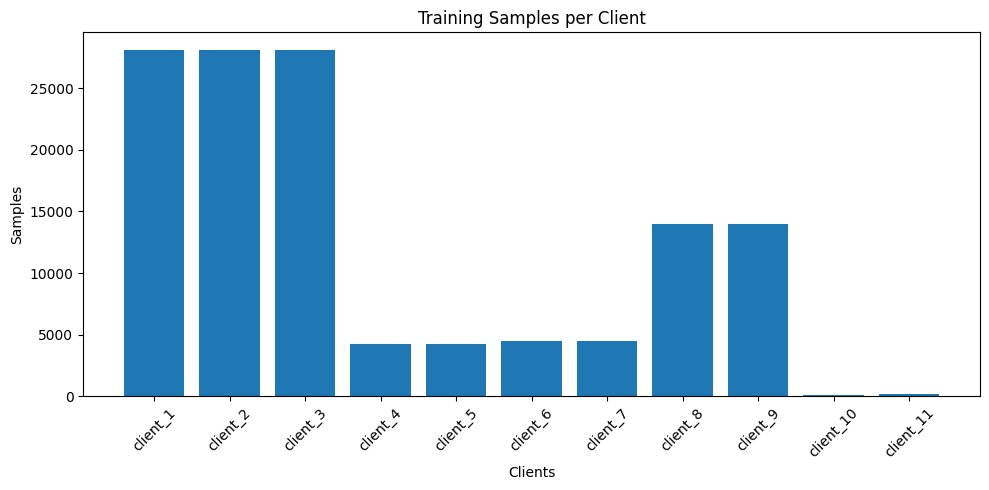

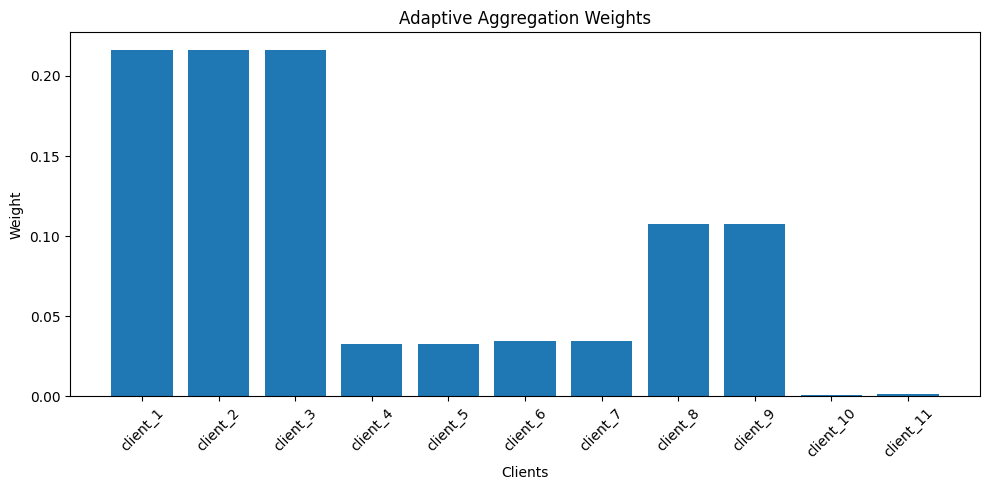

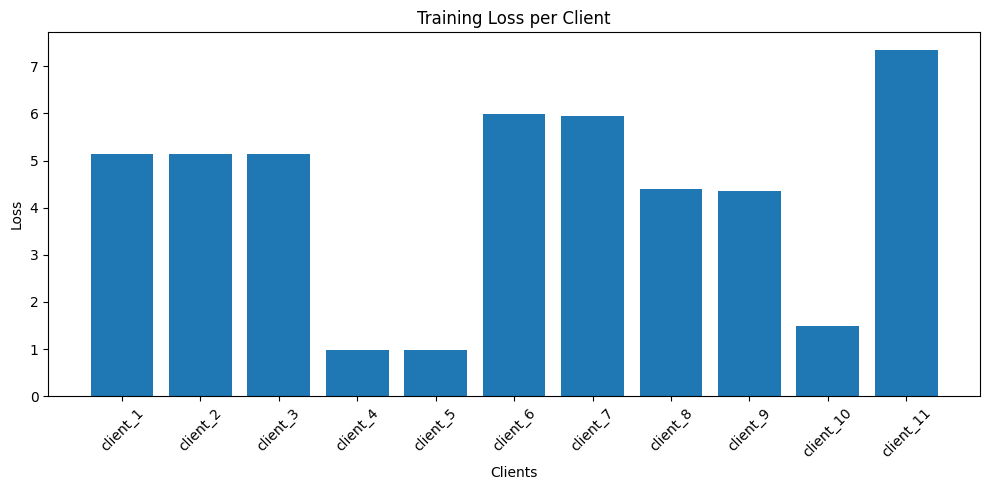

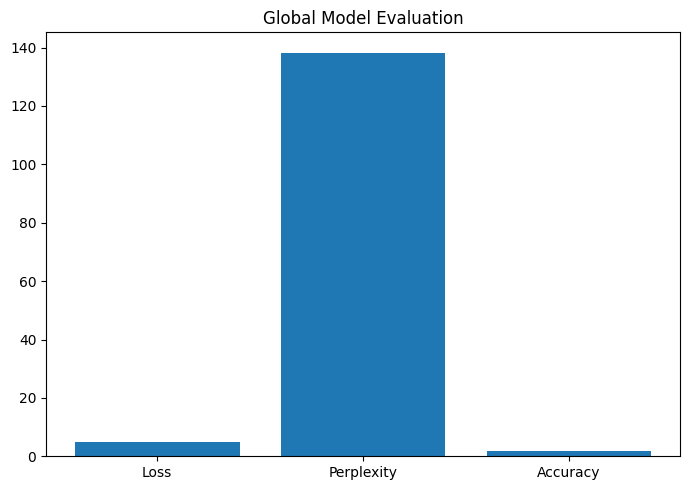



Graphs Generated Successfully

Saved in :
/content/drive/MyDrive/project/results


In [31]:
# ==========================================================
# Module 10
# Results Visualization
# Part B
# ==========================================================

import os
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Graph Folder
# ----------------------------------------------------------

GRAPH_PATH = "/content/drive/MyDrive/project/results"

os.makedirs(
    GRAPH_PATH,
    exist_ok=True
)

# ----------------------------------------------------------
# Graph 1
# Client Training Samples
# ----------------------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(
    df["client"],
    df["samples"]
)

plt.title("Training Samples per Client")

plt.xlabel("Clients")

plt.ylabel("Samples")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "client_samples.png"
    )
)

plt.show()

# ----------------------------------------------------------
# Graph 2
# Client Aggregation Weight
# ----------------------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(
    df["client"],
    df["weight"]
)

plt.title("Adaptive Aggregation Weights")

plt.xlabel("Clients")

plt.ylabel("Weight")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "client_weights.png"
    )
)

plt.show()

# ----------------------------------------------------------
# Graph 3
# Client Training Loss
# ----------------------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(
    df["client"],
    df["training_loss"]
)

plt.title("Training Loss per Client")

plt.xlabel("Clients")

plt.ylabel("Loss")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "training_loss.png"
    )
)

plt.show()

# ----------------------------------------------------------
# Graph 4
# Final Evaluation Metrics
# ----------------------------------------------------------

metric_names = [

    "Loss",

    "Perplexity",

    "Accuracy"

]

metric_values = [

    evaluation["Test Loss"],

    evaluation["Perplexity"],

    evaluation["Next Word Accuracy (%)"]

]

plt.figure(figsize=(7,5))

plt.bar(
    metric_names,
    metric_values
)

plt.title("Global Model Evaluation")

plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "evaluation_metrics.png"
    )
)

plt.show()

# ----------------------------------------------------------
# Completed
# ----------------------------------------------------------

print("\n")

print("="*60)

print("Graphs Generated Successfully")

print("="*60)

print("\nSaved in :")

print(GRAPH_PATH)

In [33]:
# ==========================================================
# Module 10 *
# Next Word Prediction
# Part A
# ==========================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from peft import PeftModel

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

MODEL_NAME = "distilgpt2"

GLOBAL_MODEL_PATH = "/content/drive/MyDrive/project/global_model"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Load Tokenizer
# ----------------------------------------------------------

print("=" * 60)
print("Loading Tokenizer...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Load Base Model
# ----------------------------------------------------------

print("\nLoading Base Model...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

# ----------------------------------------------------------
# Load Global LoRA Adapter
# ----------------------------------------------------------

print("Loading Global Federated Adapter...")

model = PeftModel.from_pretrained(
    base_model,
    GLOBAL_MODEL_PATH
)

model.to(DEVICE)

model.eval()

print("\nGlobal Federated Model Ready!")

print("=" * 60)


# ==========================================================
# Module 10
# Next Word Prediction
# Part B
# ==========================================================

def predict_next_word(text):

    inputs = tokenizer(

        text,

        return_tensors="pt"

    ).to(DEVICE)

    with torch.no_grad():

        outputs = model.generate(

            **inputs,

            max_new_tokens=5,

            do_sample=True,

            temperature=0.8,

            top_k=50,

            top_p=0.95,

            pad_token_id=tokenizer.eos_token_id

        )

    generated = tokenizer.decode(

        outputs[0],

        skip_special_tokens=True

    )

    return generated

# ----------------------------------------------------------
# Interactive Prediction
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("Next Word Prediction")
print("=" * 60)

while True:

    sentence = input("\nEnter Text (type 'exit' to quit): ")

    if sentence.lower() == "exit":

        break

    prediction = predict_next_word(sentence)

    print("\nPrediction :")

    print(prediction)

print("\nPrediction Session Ended.")

Loading Tokenizer...

Loading Base Model...
Loading Global Federated Adapter...

Global Federated Model Ready!


Next Word Prediction

Enter Text (type 'exit' to quit): Artificial Intelligence is

Prediction :
Artificial Intelligence is a tool of choice that

Enter Text (type 'exit' to quit): Machine Learning helps

Prediction :
Machine Learning helps me to understand how to

Enter Text (type 'exit' to quit): நான் இன்று

Prediction :
நான் இன்றுக�

Enter Text (type 'exit' to quit): Vanakkam how

Prediction :
Vanakkam how to take care of our

Enter Text (type 'exit' to quit): exit

Prediction Session Ended.


In [34]:
# ==========================================================
# Module 10
# Next Word Prediction
# Part C
# ==========================================================

import torch
import torch.nn.functional as F

# ----------------------------------------------------------
# Predict Only One Next Word
# ----------------------------------------------------------

def predict_one_word(text):

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():

        outputs = model(**inputs)

        logits = outputs.logits

    next_token_logits = logits[:, -1, :]

    next_token = torch.argmax(
        next_token_logits,
        dim=-1
    )

    word = tokenizer.decode(
        next_token,
        skip_special_tokens=True
    )

    print("\nInput Sentence")
    print("-------------------------")
    print(text)

    print("\nPredicted Next Word")
    print("-------------------------")
    print(word)

    return word

# ----------------------------------------------------------
# Examples
# ----------------------------------------------------------

predict_one_word("Artificial Intelligence is")

predict_one_word("Machine learning")

predict_one_word("Deep learning can")

predict_one_word("நான் இன்று")


Input Sentence
-------------------------
Artificial Intelligence is

Predicted Next Word
-------------------------
 a

Input Sentence
-------------------------
Machine learning

Predicted Next Word
-------------------------
 is

Input Sentence
-------------------------
Deep learning can

Predicted Next Word
-------------------------
 be

Input Sentence
-------------------------
நான் இன்று

Predicted Next Word
-------------------------
�


'�'

In [ ]:
# ==========================================================
# Module 10
# Interactive Prediction
# ==========================================================

while True:

    print("\n")
    print("="*60)
    print("Adaptive Personalized Federated Learning")
    print("Next Word Prediction")
    print("="*60)

    print("1. Predict Next Word")

    print("2. Complete Sentence")

    print("3. Exit")

    choice = input("\nEnter Choice : ")

    if choice == "1":

        text = input("\nEnter Sentence : ")

        predict_one_word(text)

    elif choice == "2":

        text = input("\nEnter Sentence : ")

        result = predict_next_word(text)

        print("\nCompleted Sentence")

        print("-------------------------")

        print(result)

    elif choice == "3":

        print("\nProgram Finished.")

        break

    else:

        print("\nInvalid Choice")



Adaptive Personalized Federated Learning
Next Word Prediction
1. Predict Next Word
2. Complete Sentence
3. Exit

Enter Choice : 2

Enter Sentence : Machine learning is

Completed Sentence
-------------------------
Machine learning is a very different art.


Adaptive Personalized Federated Learning
Next Word Prediction
1. Predict Next Word
2. Complete Sentence
3. Exit

Enter Choice : 1

Enter Sentence : நான் இன்று

Input Sentence
-------------------------
நான் இன்று

Predicted Next Word
-------------------------
�


Adaptive Personalized Federated Learning
Next Word Prediction
1. Predict Next Word
2. Complete Sentence
3. Exit

Enter Choice : 2

Enter Sentence : how are 

Completed Sentence
-------------------------
how are urns to me?


Adaptive Personalized Federated Learning
Next Word Prediction
1. Predict Next Word
2. Complete Sentence
3. Exit
